In [ ]:
### Mount the Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [ ]:
file_path = '/content/drive/My Drive/AdvancedLab/MuonLifetime/week1Clean.txt'

# Take all the values in the file and convert them from hex string to decimal using base 16
disc_output = []

with open(file_path, 'r', encoding='utf-8-sig') as f: # Use 'utf-8-sig' to automatically handle BOM
  for line in f:
    # Each line contains hex values separated by spaces
    hex_values = line.strip().split() # Strip leading/trailing whitespace before splitting
    if hex_values: # Only process if there are values on the line
        decimal_values = [int(hex_value, 16) for hex_value in hex_values]
        disc_output.append(decimal_values)
      # This makes a list of lists where each entry in the disc_output list is a row in the file

# Convert list into numpy array for plotting
disc_output = np.array(disc_output)

# Convert the number of ticks to nanoseconds
disc_output = disc_output * 80

# Flatten the disc_output (which is a 2D array) to one long array for analysis
disc_output = disc_output.flatten()

# Calculate the number of bins
n_bins = int(np.sqrt(len(disc_output)))

Most occurring duration: 240.0


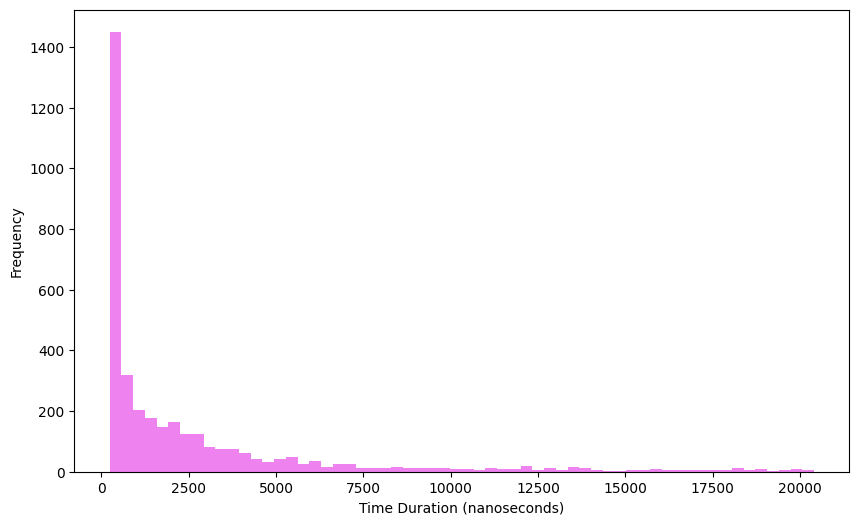

In [ ]:
# Plot disc_output as a histogram
plt.figure(figsize=(10, 6))
n, bins, patches = plt.hist(disc_output, bins= n_bins, color='violet')

# Get the x value with the highest count
max_index = bins[np.argmax(n)]

plt.xlabel('Time Duration (nanoseconds)')
plt.ylabel('Frequency')
plt.title('')


# Print out duration with the highest frequency
print(f'Most occurring duration: {max_index}')

##Double Exponential Decay Function

N(t) = A<sub>1</sub>e<sup>-t/τ<sub>+</sub> </sup> + A<sub>2</sub>e<sup>-t/τ<sub>-</sub> </sup> + C


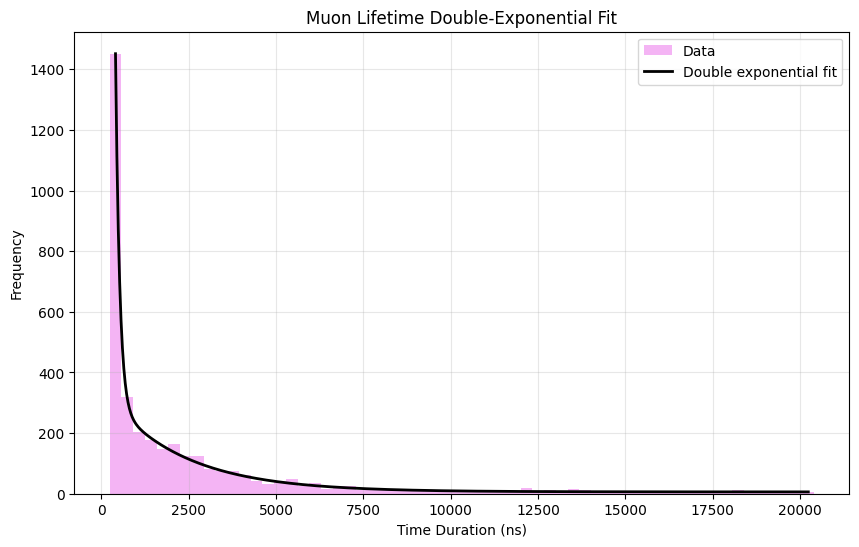

Double exponential fit results:
A1 = 340.673 ± 19.389
tau1 = 2.179 ± 0.087 μs
A2 = 37005.461 ± 14185.865
tau2 = 0.118 ± 0.013 μs
C = 6.022 ± 0.495

Final reported muon lifetime = 2.179 ± 0.087 μs


In [ ]:
# Two exponential fit

def double_exp_background(t, A1, tau1, A2, tau2, C):
    return A1 * np.exp(-t / tau1) + A2 * np.exp(-t / tau2) + C

# Initial guesses
p0_double = [
    max(y_fit), 2200,        # longer lifetime component, ns
    max(y_fit) / 2, 900,     # shorter effective lifetime component, ns
    min(y_fit)               # constant background
]

# Bounds help prevent unphysical negative amplitudes/lifetimes
bounds_double = (
    [0, 0, 0, 0, 0],          # lower bounds
    [np.inf, np.inf, np.inf, np.inf, np.inf]   # upper bounds
)

params2, covariance2 = curve_fit(
    double_exp_background,
    x_fit,
    y_fit,
    p0=p0_double,
    sigma=sigma_fit,
    absolute_sigma=True,
    bounds=bounds_double,
    maxfev=50000
)

A1, tau1, A2, tau2, C2 = params2
errors2 = np.sqrt(np.diag(covariance2))

# Convert taus and uncertainties from ns to microseconds
tau1_micro = tau1 / 1000
tau2_micro = tau2 / 1000

tau1_err_micro = errors2[1] / 1000
tau2_err_micro = errors2[3] / 1000

# Identify the longer lifetime as the positive-muon lifetime
if tau1 > tau2:
    tau_mu = tau1_micro
    tau_mu_err = tau1_err_micro
else:
    tau_mu = tau2_micro
    tau_mu_err = tau2_err_micro

# Smooth fitted curve
t_smooth = np.linspace(min(x_fit), max(x_fit), 1000)
fit_curve2 = double_exp_background(t_smooth, A1, tau1, A2, tau2, C2)

# Plot
plt.figure(figsize=(10, 6))
plt.hist(disc_output, bins=n_bins, color='violet', alpha=0.6, label='Data')
plt.plot(t_smooth, fit_curve2, color='black', linewidth=2, label='Double exponential fit')

plt.xlabel('Time Duration (ns)')
plt.ylabel('Frequency')
plt.title('Muon Lifetime Double-Exponential Fit')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Print results
print("Double exponential fit results:")
print(f"A1 = {A1:.3f} ± {errors2[0]:.3f}")
print(f"tau1 = {tau1_micro:.3f} ± {tau1_err_micro:.3f} μs")

print(f"A2 = {A2:.3f} ± {errors2[2]:.3f}")
print(f"tau2 = {tau2_micro:.3f} ± {tau2_err_micro:.3f} μs")

print(f"C = {C2:.3f} ± {errors2[4]:.3f}")

print()
print(f"Final reported muon lifetime = {tau_mu:.3f} ± {tau_mu_err:.3f} μs")

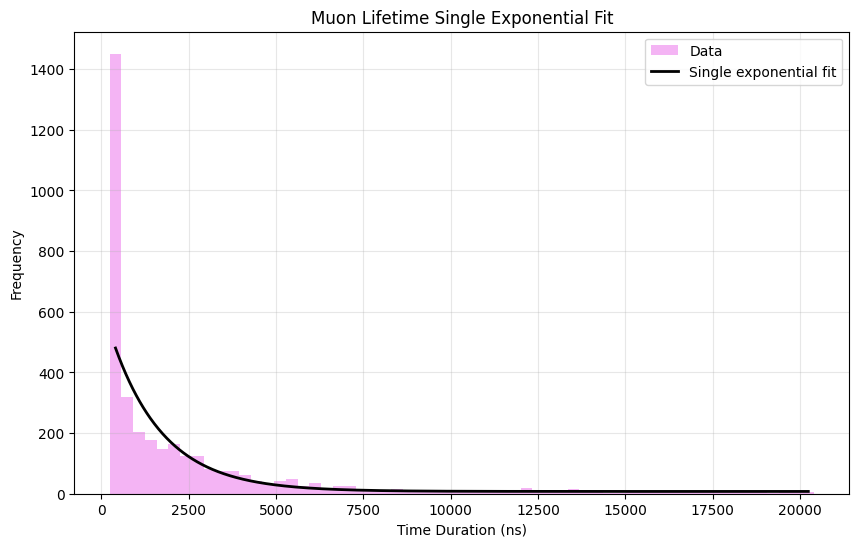

Single exponential fit results:
tau = 1.481 ± 0.045 μs
A = 622.994 ± 24.128
C = 7.511 ± 0.441


In [ ]:
# Single exponential + background fit

# Histogram data
counts, bin_edges = np.histogram(disc_output, bins=n_bins)

# Bin centers
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# Remove empty bins for fitting
mask = counts > 0
x_fit = bin_centers[mask]
y_fit = counts[mask]

# Poisson uncertainty: sigma = sqrt(N)
sigma_fit = np.sqrt(y_fit)

# Model: exponential decay + constant background
def exp_background(t, A, tau, C):
    return A * np.exp(-t / tau) + C

# Initial guesses
A_guess = max(y_fit)
tau_guess = 2200      # ns = 2.2 microseconds
C_guess = min(y_fit)

p0 = [A_guess, tau_guess, C_guess]

# Bounds prevent unphysical negative values
bounds = (
    [0, 0, 0],                  # lower bounds: A, tau, C
    [np.inf, np.inf, np.inf]    # upper bounds
)

# Fit
params, covariance = curve_fit(
    exp_background,
    x_fit,
    y_fit,
    p0=p0,
    sigma=sigma_fit,
    absolute_sigma=True,
    bounds=bounds,
    maxfev=10000
)

A, tau, C = params
A_err, tau_err, C_err = np.sqrt(np.diag(covariance))

# Convert tau and uncertainty from ns to microseconds
tau_micro = tau / 1000
tau_err_micro = tau_err / 1000

# Smooth curve for plotting
t_smooth = np.linspace(min(x_fit), max(x_fit), 1000)
fit_curve = exp_background(t_smooth, A, tau, C)

# Plot histogram + fit
plt.figure(figsize=(10, 6))
plt.hist(disc_output, bins=n_bins, color='violet', alpha=0.6, label='Data')
plt.plot(t_smooth, fit_curve, color='black', linewidth=2, label='Single exponential fit')

plt.xlabel('Time Duration (ns)')
plt.ylabel('Frequency')
plt.title('Muon Lifetime Single Exponential Fit')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Print results
print("Single exponential fit results:")
print(f"tau = {tau_micro:.3f} ± {tau_err_micro:.3f} μs")
print(f"A = {A:.3f} ± {A_err:.3f}")
print(f"C = {C:.3f} ± {C_err:.3f}")

N(t) = N<sub>0</sub>e<sup>-t/τ